# **Single Layer Unidirectional LSTM Model using word2vec**
### - (CBOW or Skipgram and any vector size from 64 to 300)

## **Import Libraries**

In [29]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from gensim.models import Word2Vec
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping
from gensim.utils import simple_preprocess
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve, auc, f1_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

## **Load Dataset**

In [31]:
# Load data
X_train = pd.read_csv("X_train.csv")["Final_Cleaned_Tweet"]
X_val = pd.read_csv("X_val.csv")["Final_Cleaned_Tweet"]
X_test = pd.read_csv("X_test.csv")["Final_Cleaned_Tweet"]

y_train = pd.read_csv("y_train.csv")["Sentiment"]
y_val = pd.read_csv("y_val.csv")["Sentiment"]
y_test = pd.read_csv("y_test.csv")["Sentiment"]

In [32]:
X_train.head

<bound method NDFrame.head of 0        truth evil becomes apparent every day american...
1        cap youngster initial arrest tan pant right ta...
2        freedom convoy organizer tamara rich return ot...
3                    tamara lich arrest fafo freedomconvoy
4        pal ukraine fight real freedom convoy forming ...
                               ...                        
26900                                u freedom convoy move
26901    freedom convoy end mandate unite people jab wo...
26902    823true freedom convoy 2022 register register ...
26903    crown try put freedom convoy leader tamara ric...
26904    could cost job percent canadian would vote wea...
Name: Final_Cleaned_Tweet, Length: 26905, dtype: object>

### **Label Encoding**

In [34]:
# Encode labels
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc = le.transform(y_val)
y_test_enc = le.transform(y_test)

## **Tokenization**

In [36]:
# Convert all entries to string and handle NaNs
X_train = X_train.fillna("").astype(str)
X_val = X_val.fillna("").astype(str)
X_test = X_test.fillna("").astype(str)

# Now combine all for tokenizer
all_text = pd.concat([X_train, X_val, X_test])

In [37]:
# Fit tokenizer on all text data
all_text = pd.concat([X_train, X_val, X_test])
tokenizer = Tokenizer()
tokenizer.fit_on_texts(all_text)
vocab_size = len(tokenizer.word_index) + 1

# Convert text to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Padding
max_len = max(len(seq) for seq in X_train_seq)
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

## **Embedding - Word2Vec (Skip-gram)**

In [39]:
# Train Word2Vec (Skip-gram)
tokenized_sentences = [sentence.split() for sentence in all_text]
embedding_dim = 100
w2v_model = Word2Vec(sentences=tokenized_sentences, vector_size=embedding_dim, window=5, min_count=1, sg=1)

# Create embedding matrix
embedding_matrix = np.zeros((vocab_size, embedding_dim))
for word, i in tokenizer.word_index.items():
    if word in w2v_model.wv:
        embedding_matrix[i] = w2v_model.wv[word]

In [40]:
model = Sequential()
model.add(Embedding(input_dim=vocab_size,
                    output_dim=embedding_dim,
                    weights=[embedding_matrix],
                    trainable=False))
model.add(LSTM(128))
model.add(Dropout(0.5))
model.add(Dense(5, activation='softmax'))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Build model explicitly
model.build(input_shape=(None,max_len))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 51, 100)             │       3,105,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 128)                 │         117,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,223,093 (12.30 MB)

 Trainable params: 117,893 (460.52 KB)

 Non-trainable params: 3,105,200 (11.85 MB)

In [41]:
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

history = model.fit(X_train_pad, y_train_enc,
                    validation_data=(X_val_pad, y_val_enc),
                    epochs=10,
                    batch_size=64,
                    callbacks=[early_stop],
                    verbose=1)

Epoch 1/10
421/421 ━━━━━━━━━━━━━━━━━━━━ 45s 94ms/step - accuracy: 0.2750 - loss: 1.5466 - val_accuracy: 0.4462 - val_loss: 1.3923
Epoch 2/10
421/421 ━━━━━━━━━━━━━━━━━━━━ 40s 93ms/step - accuracy: 0.3642 - loss: 1.4503 - val_accuracy: 0.3215 - val_loss: 1.4758
Epoch 3/10
421/421 ━━━━━━━━━━━━━━━━━━━━ 39s 89ms/step - accuracy: 0.3726 - loss: 1.4335 - val_accuracy: 0.5648 - val_loss: 1.1880
Epoch 4/10
421/421 ━━━━━━━━━━━━━━━━━━━━ 40s 87ms/step - accuracy: 0.4009 - loss: 1.3959 - val_accuracy: 0.5445 - val_loss: 1.2236
Epoch 5/10
421/421 ━━━━━━━━━━━━━━━━━━━━ 42s 99ms/step - accuracy: 0.4083 - loss: 1.3795 - val_accuracy: 0.4750 - val_loss: 1.3403


## **Model Evaluation**

In [43]:
loss, acc = model.evaluate(X_train_pad, y_train_enc)
print(f"Train Accuracy: {acc:.2f}")

841/841 ━━━━━━━━━━━━━━━━━━━━ 22s 27ms/step - accuracy: 0.2113 - loss: 1.6207
Train Accuracy: 0.39


In [44]:
loss, acc = model.evaluate(X_test_pad, y_test_enc)
print(f"Test Accuracy: {acc:.2f}")

235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.5637 - loss: 1.1759
Test Accuracy: 0.57


In [45]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 51, 100)             │       3,105,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 128)                 │         117,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,458,881 (13.19 MB)

 Trainable params: 117,893 (460.52 KB)

 Non-trainable params: 3,105,200 (11.85 MB)

 Optimizer params: 235,788 (921.05 KB)

### Confusion Matrix

#### Train Set

841/841 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step
841/841 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step


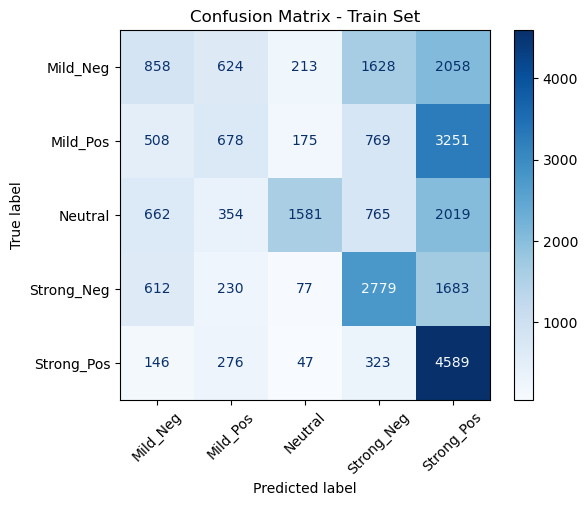

              precision    recall  f1-score   support

    Mild_Neg       0.31      0.16      0.21      5381
    Mild_Pos       0.31      0.13      0.18      5381
     Neutral       0.76      0.29      0.42      5381
  Strong_Neg       0.44      0.52      0.48      5381
  Strong_Pos       0.34      0.85      0.48      5381

    accuracy                           0.39     26905
   macro avg       0.43      0.39      0.35     26905
weighted avg       0.43      0.39      0.35     26905



In [48]:
# Predictions & probabilities
y_train_pred = np.argmax(model.predict(X_train_pad), axis=1)
y_train_proba = model.predict(X_train_pad)

# Confusion Matrix
cm = confusion_matrix(y_train_enc, y_train_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix - Train Set")
plt.show()

# Classification report (includes F1, precision, recall)
report = classification_report(y_train_enc, y_train_pred, target_names=le.classes_, output_dict=True)
print(classification_report(y_train_enc, y_train_pred, target_names=le.classes_))

#### Test Set

235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step


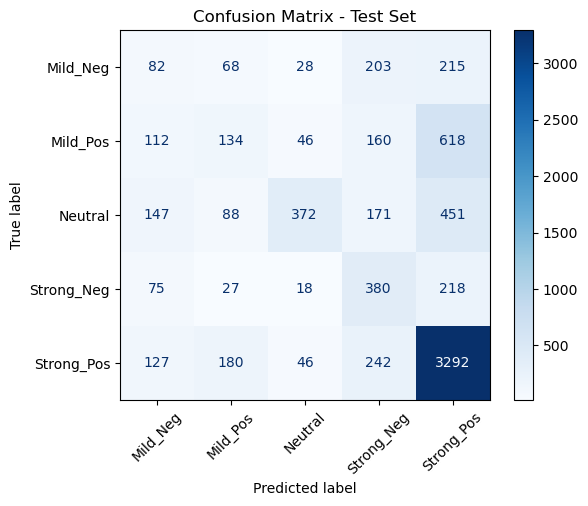

              precision    recall  f1-score   support

    Mild_Neg       0.15      0.14      0.14       596
    Mild_Pos       0.27      0.13      0.17      1070
     Neutral       0.73      0.30      0.43      1229
  Strong_Neg       0.33      0.53      0.41       718
  Strong_Pos       0.69      0.85      0.76      3887

    accuracy                           0.57      7500
   macro avg       0.43      0.39      0.38      7500
weighted avg       0.56      0.57      0.54      7500



In [50]:
# Predictions & probabilities
y_test_pred = np.argmax(model.predict(X_test_pad), axis=1)
y_test_proba = model.predict(X_test_pad)

# Confusion Matrix
cm = confusion_matrix(y_test_enc, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix - Test Set")
plt.show()

# Classification report (includes F1, precision, recall)
report = classification_report(y_test_enc, y_test_pred, target_names=le.classes_, output_dict=True)
print(classification_report(y_test_enc, y_test_pred, target_names=le.classes_))

### F1 Score

#### Train Set

In [53]:
# Macro, Micro, Weighted
f1_macro = f1_score(y_train_enc, y_train_pred, average='macro')
f1_micro = f1_score(y_train_enc, y_train_pred, average='micro')
f1_weighted = f1_score(y_train_enc, y_train_pred, average='weighted')

print(f"Macro F1 Score: {f1_macro:.4f}")
print(f"Micro F1 Score: {f1_micro:.4f}")
print(f"Weighted F1 Score: {f1_weighted:.4f}")

Macro F1 Score: 0.3548
Micro F1 Score: 0.3897
Weighted F1 Score: 0.3548


#### Test Set

In [55]:
# Macro, Micro, Weighted
f1_macro = f1_score(y_test_enc, y_test_pred, average='macro')
f1_micro = f1_score(y_test_enc, y_test_pred, average='micro')
f1_weighted = f1_score(y_test_enc, y_test_pred, average='weighted')

print(f"Macro F1 Score: {f1_macro:.4f}")
print(f"Micro F1 Score: {f1_micro:.4f}")
print(f"Weighted F1 Score: {f1_weighted:.4f}")

Macro F1 Score: 0.3814
Micro F1 Score: 0.5680
Weighted F1 Score: 0.5378


#### ROC AUC Plot (One-vs-Rest)

#### Train Set

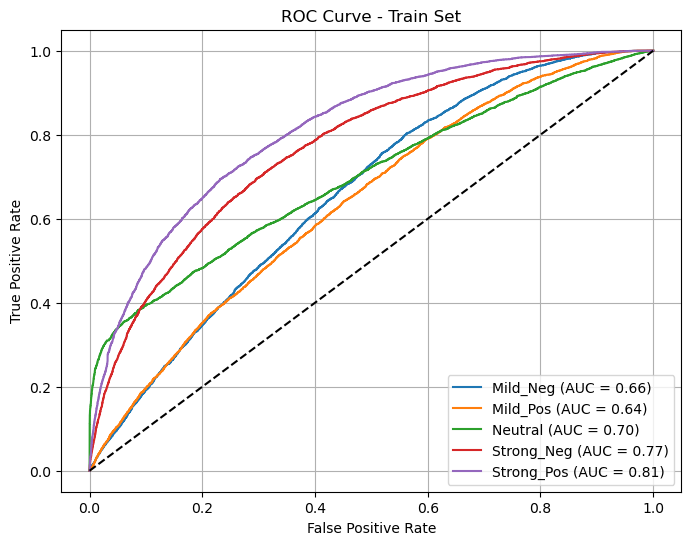

In [58]:
# Binarize the output for ROC
y_true_bin = label_binarize(y_train_enc, classes=range(len(le.classes_)))

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(len(le.classes_)):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_train_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(8, 6))
for i in range(len(le.classes_)):
    plt.plot(fpr[i], tpr[i], label=f"{le.classes_[i]} (AUC = {roc_auc[i]:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve - Train Set")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()

#### Test Set

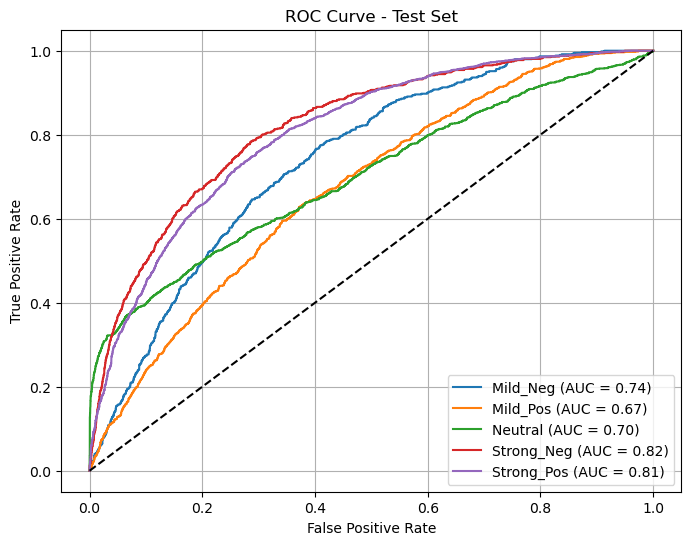

In [60]:
# Binarize the output for ROC
y_true_bin = label_binarize(y_test_enc, classes=range(len(le.classes_)))

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(len(le.classes_)):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_test_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(8, 6))
for i in range(len(le.classes_)):
    plt.plot(fpr[i], tpr[i], label=f"{le.classes_[i]} (AUC = {roc_auc[i]:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve - Test Set")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()

# **Model Tuning**

### **Iteration #1- Allow Embedding Layer to Fine-Tune (Trainable=True)**

This approach will help backpropagation to update the Word2Vec vectors

### Model Training

In [64]:
model = Sequential()
model.add(Embedding(input_dim=vocab_size,
                    output_dim=embedding_dim,
                    weights=[embedding_matrix],
                    trainable=True))
model.add(LSTM(128))
model.add(Dropout(0.5))
model.add(Dense(5, activation='softmax'))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Build model explicitly
model.build(input_shape=(None,max_len))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ (None, 51, 100)             │       3,105,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 128)                 │         117,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,223,093 (12.30 MB)

 Trainable params: 3,223,093 (12.30 MB)

 Non-trainable params: 0 (0.00 B)

In [65]:
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

history = model.fit(X_train_pad, y_train_enc,
                    validation_data=(X_val_pad, y_val_enc),
                    epochs=10,
                    batch_size=64,
                    callbacks=[early_stop],
                    verbose=1)

Epoch 1/10
421/421 ━━━━━━━━━━━━━━━━━━━━ 53s 113ms/step - accuracy: 0.2812 - loss: 1.5491 - val_accuracy: 0.4635 - val_loss: 1.2624
Epoch 2/10
421/421 ━━━━━━━━━━━━━━━━━━━━ 84s 118ms/step - accuracy: 0.4542 - loss: 1.2932 - val_accuracy: 0.5440 - val_loss: 1.1587
Epoch 3/10
421/421 ━━━━━━━━━━━━━━━━━━━━ 48s 114ms/step - accuracy: 0.5492 - loss: 1.1297 - val_accuracy: 0.4715 - val_loss: 1.2606
Epoch 4/10
421/421 ━━━━━━━━━━━━━━━━━━━━ 47s 112ms/step - accuracy: 0.6104 - loss: 0.9894 - val_accuracy: 0.4787 - val_loss: 1.4493


### Model Evaluation

In [67]:
loss, acc = model.evaluate(X_train_pad, y_train_enc)
print(f"Train Accuracy: {acc:.2f}")

841/841 ━━━━━━━━━━━━━━━━━━━━ 24s 28ms/step - accuracy: 0.4793 - loss: 1.2672
Train Accuracy: 0.56


In [68]:
loss, acc = model.evaluate(X_test_pad, y_test_enc)
print(f"Test Accuracy: {acc:.2f}")

235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.5551 - loss: 1.1462
Test Accuracy: 0.56


#### Confusion Matrix

841/841 ━━━━━━━━━━━━━━━━━━━━ 23s 26ms/step
841/841 ━━━━━━━━━━━━━━━━━━━━ 21s 24ms/step


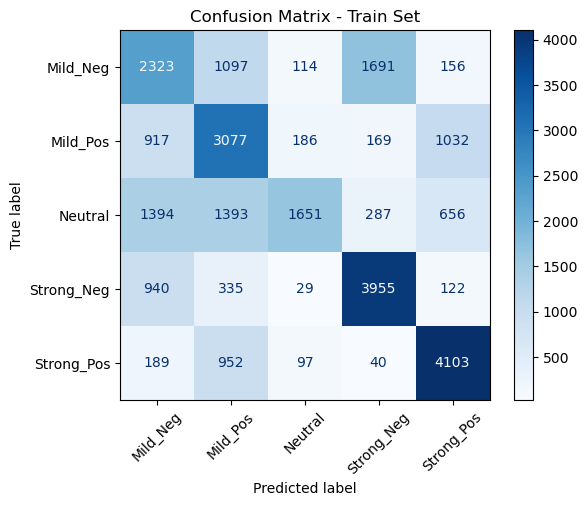

              precision    recall  f1-score   support

    Mild_Neg       0.40      0.43      0.42      5381
    Mild_Pos       0.45      0.57      0.50      5381
     Neutral       0.79      0.31      0.44      5381
  Strong_Neg       0.64      0.73      0.69      5381
  Strong_Pos       0.68      0.76      0.72      5381

    accuracy                           0.56     26905
   macro avg       0.59      0.56      0.55     26905
weighted avg       0.59      0.56      0.55     26905



In [70]:
# Predictions & probabilities
y_train_pred = np.argmax(model.predict(X_train_pad), axis=1)
y_train_proba = model.predict(X_train_pad)

# Confusion Matrix
cm = confusion_matrix(y_train_enc, y_train_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix - Train Set")
plt.show()

# Classification report (includes F1, precision, recall)
report = classification_report(y_train_enc, y_train_pred, target_names=le.classes_, output_dict=True)
print(classification_report(y_train_enc, y_train_pred, target_names=le.classes_))

235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step


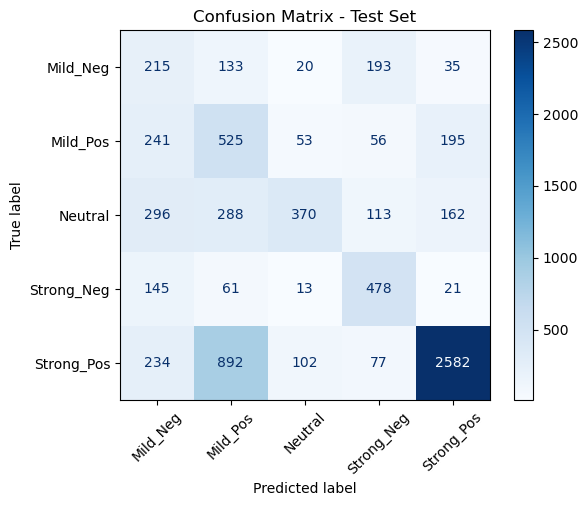

              precision    recall  f1-score   support

    Mild_Neg       0.19      0.36      0.25       596
    Mild_Pos       0.28      0.49      0.35      1070
     Neutral       0.66      0.30      0.41      1229
  Strong_Neg       0.52      0.67      0.58       718
  Strong_Pos       0.86      0.66      0.75      3887

    accuracy                           0.56      7500
   macro avg       0.50      0.50      0.47      7500
weighted avg       0.66      0.56      0.58      7500



In [71]:
# Predictions & probabilities
y_test_pred = np.argmax(model.predict(X_test_pad), axis=1)
y_test_proba = model.predict(X_test_pad)

# Confusion Matrix
cm = confusion_matrix(y_test_enc, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix - Test Set")
plt.show()

# Classification report (includes F1, precision, recall)
report = classification_report(y_test_enc, y_test_pred, target_names=le.classes_, output_dict=True)
print(classification_report(y_test_enc, y_test_pred, target_names=le.classes_))

#### F1 Score

In [73]:
# Macro, Micro, Weighted
f1_macro = f1_score(y_train_enc, y_train_pred, average='macro')
f1_micro = f1_score(y_train_enc, y_train_pred, average='micro')
f1_weighted = f1_score(y_train_enc, y_train_pred, average='weighted')
print("Train Set")
print(f"Macro F1 Score: {f1_macro:.4f}")
print(f"Micro F1 Score: {f1_micro:.4f}")
print(f"Weighted F1 Score: {f1_weighted:.4f}")

Train Set
Macro F1 Score: 0.5532
Micro F1 Score: 0.5616
Weighted F1 Score: 0.5532


In [74]:
# Macro, Micro, Weighted
f1_macro = f1_score(y_test_enc, y_test_pred, average='macro')
f1_micro = f1_score(y_test_enc, y_test_pred, average='micro')
f1_weighted = f1_score(y_test_enc, y_test_pred, average='weighted')
print("Test Set")
print(f"Macro F1 Score: {f1_macro:.4f}")
print(f"Micro F1 Score: {f1_micro:.4f}")
print(f"Weighted F1 Score: {f1_weighted:.4f}")

Test Set
Macro F1 Score: 0.4704
Micro F1 Score: 0.5560
Weighted F1 Score: 0.5830


#### ROC AUC Plot (One-vs-Rest)

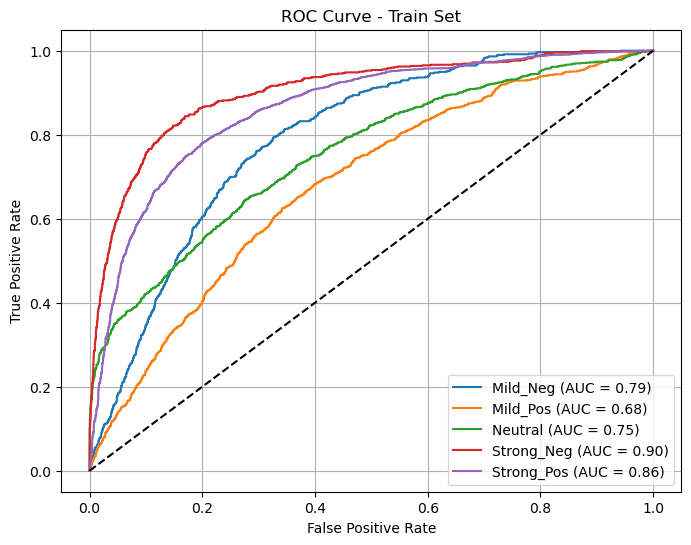

In [76]:
# Binarize the output for ROC
y_true_bin = label_binarize(y_test_enc, classes=range(len(le.classes_)))

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(len(le.classes_)):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_test_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(8, 6))
for i in range(len(le.classes_)):
    plt.plot(fpr[i], tpr[i], label=f"{le.classes_[i]} (AUC = {roc_auc[i]:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve - Train Set")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()

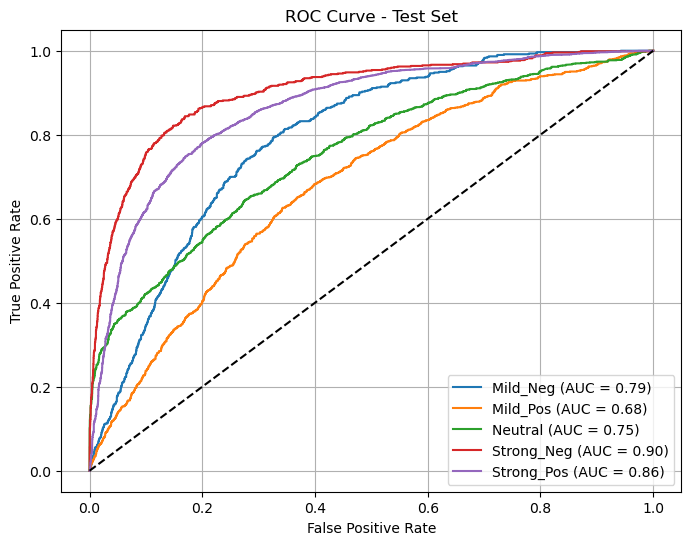

In [77]:
# Binarize the output for ROC
y_true_bin = label_binarize(y_test_enc, classes=range(len(le.classes_)))

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(len(le.classes_)):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_test_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(8, 6))
for i in range(len(le.classes_)):
    plt.plot(fpr[i], tpr[i], label=f"{le.classes_[i]} (AUC = {roc_auc[i]:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve - Test Set")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()